# **Locgistic Regression With ROC And AUC Score**

In [48]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

generate 2 class dataset

In [49]:
X,y = make_classification(n_samples = 1000, n_classes=2, random_state=2)

split the dataset into train test

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=0)

Created a dummy model with default 0 as output(majority class)

In [51]:
dummy_model_prob=[0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

create a basic logistic model

In [52]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

prediction based on probability

In [53]:
model_prob = model.predict_proba(X_test)

focus on positive outcome

In [54]:
model_prob = model_prob[:,1]

In [55]:
model_prob

array([9.96782494e-01, 2.47649983e-01, 9.85038167e-01, 1.19816131e-01,
       8.99251277e-03, 3.20923459e-02, 5.50576283e-01, 9.83543301e-01,
       9.83339330e-01, 8.88807418e-01, 1.19184207e-01, 1.41217602e-01,
       9.90973101e-01, 9.94869373e-01, 1.60205460e-02, 1.32929291e-02,
       6.34181179e-01, 9.40834904e-01, 9.96643187e-01, 1.55614244e-01,
       9.89400870e-01, 4.44985115e-01, 9.22350335e-01, 9.81283991e-01,
       1.73197769e-01, 4.41905294e-01, 8.56615663e-01, 2.21966409e-04,
       1.82452597e-02, 9.70351999e-01, 9.97497195e-01, 9.69892938e-01,
       4.68848675e-01, 9.57724457e-01, 3.27695066e-01, 1.14617403e-02,
       9.99148223e-01, 1.12198426e-01, 3.04345745e-03, 6.55865241e-01,
       9.40935912e-01, 8.06318964e-01, 2.04219954e-01, 1.80627043e-02,
       6.60061740e-01, 9.59602805e-01, 2.14375825e-02, 1.26992369e-01,
       5.44142521e-03, 9.76108503e-01, 3.15104271e-02, 5.26133913e-01,
       3.78382185e-02, 1.39492295e-01, 3.42863875e-02, 8.35746694e-01,
      

calculating the score

In [56]:
dummy_model_auc = roc_auc_score(y_test,dummy_model_prob)
model_auc=roc_auc_score(y_test,model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.9478906600089622


Calculate the ROC Curve

In [57]:
dummy_fpr, dummy_tpr,_=roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr,threshold=roc_curve(y_test,model_prob)

In [58]:
threshold

array([           inf, 9.99902771e-01, 8.35746694e-01, 8.32764261e-01,
       7.18454682e-01, 7.08371663e-01, 6.76722579e-01, 6.64969473e-01,
       6.59913559e-01, 6.53648120e-01, 6.34181179e-01, 5.60559911e-01,
       5.56202032e-01, 5.50576283e-01, 5.32441171e-01, 5.19202006e-01,
       5.19151847e-01, 4.83946185e-01, 4.77561968e-01, 3.27695066e-01,
       2.61296309e-01, 2.58714777e-01, 2.47649983e-01, 2.10303969e-01,
       2.06966189e-01, 1.55109191e-01, 1.45276911e-01, 1.39492295e-01,
       1.34453448e-01, 1.29291357e-01, 1.27827099e-01, 1.20060158e-01,
       1.19816131e-01, 1.15040841e-01, 1.12198426e-01, 7.35549716e-02,
       6.64044937e-02, 9.40433077e-03, 8.99251277e-03, 2.26391820e-03,
       1.86878759e-03, 2.21966409e-04])

In [59]:
import matplotlib.pyplot as plt
from matplotlib import pyplot

plot the ROC Curve for the model

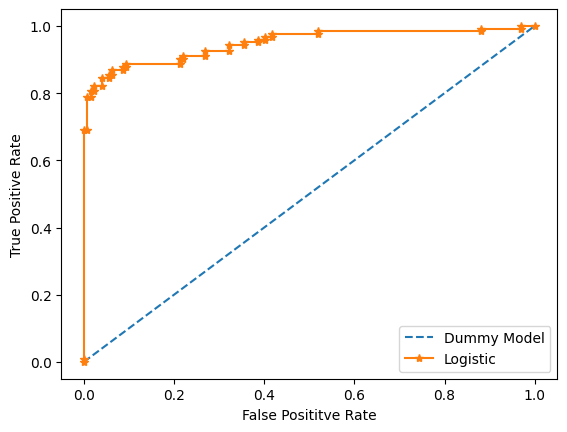

In [60]:
pyplot.plot(dummy_fpr,dummy_tpr, linestyle='--',label='Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker='*',label='Logistic')
# Axis label
pyplot.xlabel('False Posititve Rate')
pyplot.ylabel('True Positive Rate')
# Show thw legend
pyplot.legend()
pyplot.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


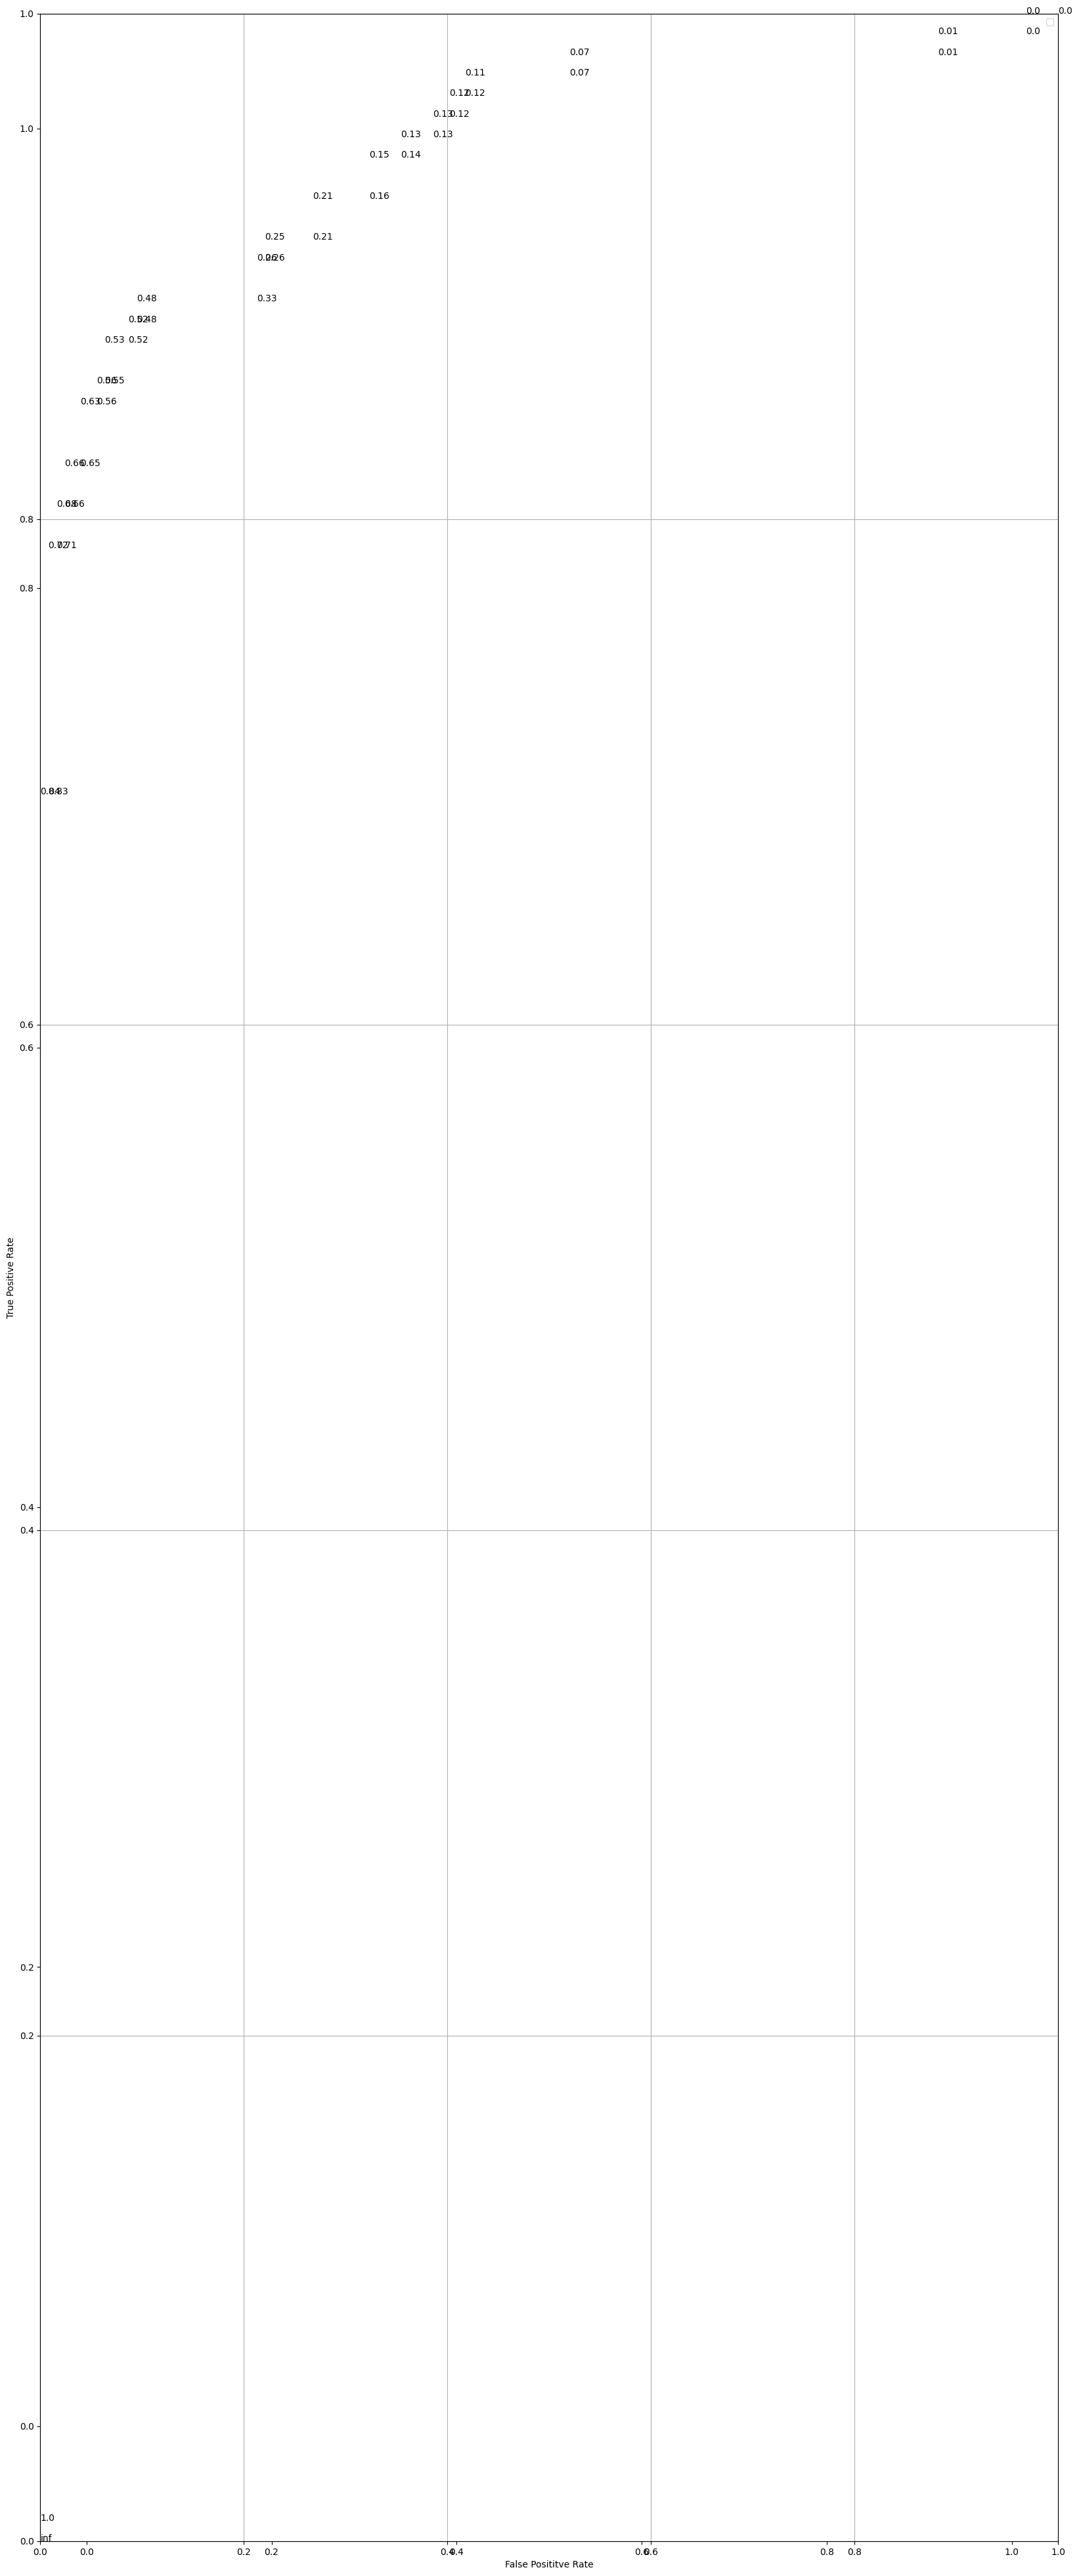

In [ ]:
import numpy as np
fig = pyplot.figure(figsize=(20,50))
pyplot.plot(dummy_fpr,dummy_tpr, linestyle='--',label='Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker='*',label='Logistic')
ax=fig.add_subplot(111)
for xyz in zip(model_fpr, model_tpr, threshold):
    ax.annotate('%s' % np.round(xyz[2],2),xy=(xyz[0],xyz[1]))
# Axis label
pyplot.xlabel('False Posititve Rate')
pyplot.ylabel('True Positive Rate')
# Show thw legend
pyplot.legend()
pyplot.show()


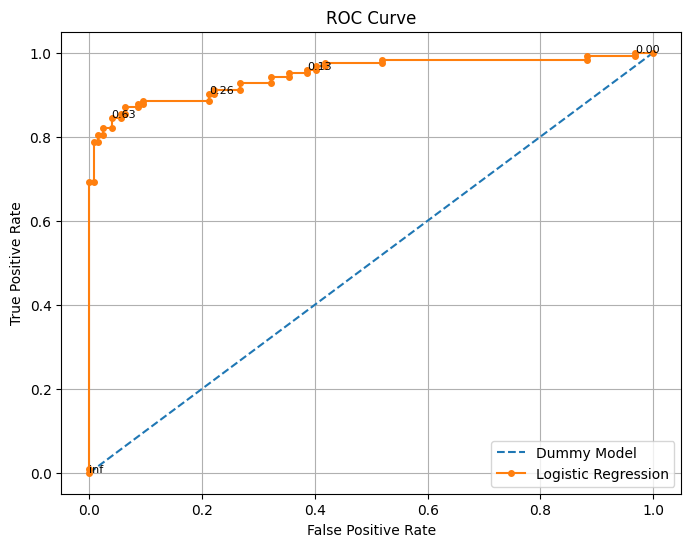

In [65]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(dummy_fpr, dummy_tpr, '--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='o', markersize=4, label='Logistic Regression')

# Annotate every 10th threshold
for i, (fpr, tpr, thr) in enumerate(zip(model_fpr, model_tpr, threshold)):
    if i % 10 == 0:
        ax.annotate(f'{thr:.2f}', (fpr, tpr), fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.grid(True)
ax.legend()

plt.show()